In [13]:
from sklearn.linear_model  import Lasso
from sklearn.metrics import mean_squared_error 
import pandas as pd
from sklearn.model_selection import train_test_split

In [23]:
df = pd.read_csv("Healthinsurance.csv")

X= df.drop(columns = ["charges"] )
y = df["charges"]
X = pd.get_dummies(X,columns = ["region"],drop_first=True,dtype=int)
X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.2,random_state=42)

MSE for alpha=0.001 33597770.05720263
MSE for alpha=0.1 33597770.05720263
MSE for alpha=0.2 33597770.05720263
MSE for alpha=1 33597770.05720263
MSE for alpha=2 33597770.05720263
MSE for alpha=3 33597770.05720263
MSE for alpha=4 33597770.05720263
MSE for alpha=5 33597770.05720263
MSE for alpha=6 33597770.05720263
MSE for alpha=7 33597770.05720263
MSE for alpha=10 33597770.05720263
MSE for alpha=20 33597770.05720263
MSE for alpha=30 33597770.05720263
MSE for alpha=40 33597770.05720263
MSE for alpha=50 33597770.05720263
MSE for alpha=100 33597770.05720263


<Axes: >

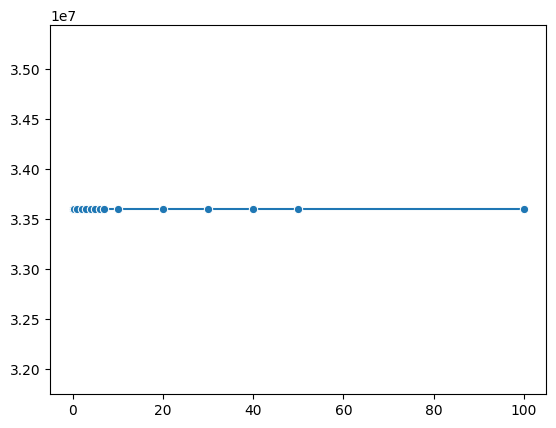

In [24]:
import seaborn as sns
alphas = [0.001,0.1,0.2,1,2,3,4,5,6,7,10,20,30,40,50,100]
mses = []
for a in alphas:
    lasso_model = Lasso(alpha = 0.1)
    lasso_model.fit(X_train,y_train)
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha={a}" ,mse)
    mses.append(mse)
    
sns.lineplot(x= alphas,y= mses,marker = "o")

In [32]:
# LasoCv
#  cross validation krta hain
from sklearn.linear_model  import LassoCV
alphas = [0.001,0.1,0.2,1,2,3,4,5,6,7,10,20,30,40,50,100]
lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter=1000,
    random_state = 42
    
)
lasso_cv_model.fit(X_train,y_train)
print("best alpha :",lasso_cv_model.alpha_)
y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("MSE:",mse)

best alpha : 89.2161025213486
MSE: 34210457.68943394
